# Figure 4, Part 2: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-06-30 12:04:50,992::INFO::settings.py::Setting loglevel to INFO
2025-06-30 12:04:50,993::INFO::settings.py::Setting stores to {}
2025-06-30 12:04:50,994::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-06-30 12:04:50,994::INFO::settings.py::Setting database.misc.create_tables to True
2025-06-30 12:04:50,995::INFO::settings.py::Setting enable_python_native_blobs to True
2025-06-30 12:04:50,995::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-06-30 12:04:50,997::INFO::settings.py::Setting database.user to celia
2025-06-30 12:04:50,998::INFO::settings.py::Setting database.password to celia_mathislab


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-06-30 12:04:51,246::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
2025-06-30 12:04:51,354::INFO::table.py::could not log event in table ~log
2025-06-30 12:04:51,787::INFO::table.py::could not log event in table ~log
2025-06-30 12:04:51,787::INFO::table.py::could not log event in table ~log
2025-06-30 12:04:52,279::INFO::table.py::could not log event in table ~log
2025-06-30 12:04:52,279::INFO::table.py::could not log event in table ~log
2025-06-30 12:04:52,434::INFO::table.py::could not log event in table ~log
2025-06-30 12:04:52,434::INFO::table.py::could not log event in table ~log
2025-06-30 12:04:52,815::INFO::table.py::could not log event in table ~log
2025-06-30 12:04:52,815::INFO::table.py::could not log event in table ~log
2025-06-30 12:04:53,156::INFO::table.py::could not log event in table ~log
2025-06-30 12:04:53,156::INFO::table.py::could not log event in table ~log


In [38]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils
from vr4mice.analysis import regression
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanVelocities
from vr4mice.schema.session_metrics import SessionMetrics, TrialMetrics
from vr4mice.schema.vr4mice import Groups, Labels, Dataset

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats

from vr4mice.analysis.stats import get_p_values_multi, get_multi_performance_p_val, plot_aperture_heatmap


style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [5]:
trial_df = (Groups() * (Labels()  & 'label = "ar_paper"') * (Dataset() & 'session_label = "ar_discrim_5_occluders"') * TrialMetrics()).fetch(as_dict=True)
trial_df = pd.concat([pd.DataFrame(x) for x in trial_df])
trial_df ["aperture"] = trial_df.aperture.round(2)
trial_df, reward_table = utils.multi_occluder_inclusion_criteria(trial_df[["dataset", "aperture", "trial", "trial_left_choice", "trial_rewarded", "trial_tortuosity", "trial_duration"]], threshold_drop=.25, return_excluded=False)
# Create list of included datasets
mouse_list = trial_df.dataset.unique()


Excluded datasets:  ['31726_2025-03-25_1' '31726_2025-03-26_1' '31728_2025-03-10_1'
 '31728_2025-03-12_1' '31728_2025-03-17_1' 'Jacana_2024-08-20_1'
 'Lemming_2024-08-16_1' 'Oribi_2024-08-23_1' 'Oribi_2024-08-28_1'
 'Pheasant_2024-08-23_1' 'Pheasant_2024-08-27_2']


In [ ]:
# fetch the interpolated trials from the included datasets
# This takes a while to fetch because we need to fetch data for all trials (4 min 20 secs) 
inter_df = []
for m in mouse_list:
    try:
        #print(m)
        inter_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch(as_dict=True)[0]))
    except Exception as err:
        print(err)
inter_df = pd.concat(inter_df)

inter_df["mouse_name"] = inter_df.dataset.str.split("_").str [0]

In [7]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

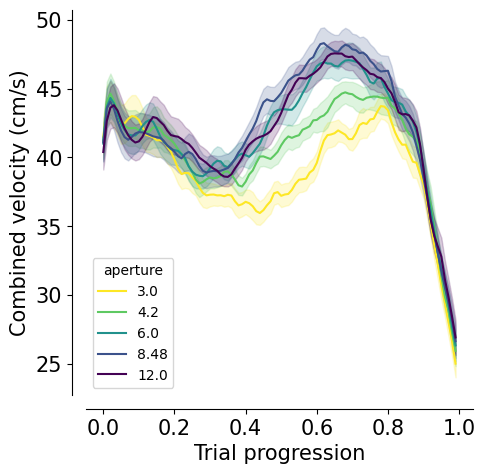

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax = ax
mean_mouse = inter_df.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

mean_mouse.sort_values("aperture", inplace=True)
mean_mouse["aperture"] = mean_mouse.aperture.astype("str")

sns.lineplot(
    data=mean_mouse,
    x="trial_length",
    y="velocity",
    palette=plotting.colors_multi_aperture,
    hue="aperture",
    errorbar="se",
    ax=ax,
)

sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
#plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "figure4_multi_occluder_velocity.svg", transparent=False)

In [86]:
# TODO This fecth call is a little slow, maybe we should add an optimal p table
optimal_df = []
for m in mouse_list:
    print(m)
    optimal_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "trial", "aperture", "optimal_p", as_dict=True)[0]))
optimal_df = pd.concat(optimal_df)

# Create list of included datasets
mouse_list = optimal_df.dataset.unique()
optimal_df["mouse_name"] = optimal_df.dataset.str.split("_").str [0]

optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "trial", "aperture"], as_index=False).mean()
optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "aperture"], as_index=False).mean()

31726_2025-03-27_1
31726_2025-03-28_1
31728_2025-03-11_1
31728_2025-03-14_1
J729_2024-12-11_1
J729_2024-12-12_1
J729_2024-12-13_1
J729_2024-12-15_1
Jacana_2024-08-21_1
Jacana_2024-08-22_1
Kiwi_2024-08-19_1
Kiwi_2024-08-20_1
Kiwi_2024-08-21_1
Lemming_2024-08-14_1
Lemming_2024-08-15_1
Lemming_2024-08-19_1
Nightingale_2024-08-15_1
Nightingale_2024-08-16_1
Nightingale_2024-08-21_1
Nightingale_2024-08-22_1
Oribi_2024-08-26_1
Oribi_2024-08-27_1
Oribi_2024-08-29_1
Pheasant_2024-08-26_1
Pheasant_2024-08-28_1


In [94]:
optimal_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    optimal_df.loc[optimal_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2025-06-30 15:47:26,983::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:47:26,983::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:47:26,990::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:47:26,990::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:47:27,084::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=1.550443301065852, pvalue=0.13412281968155934, df=24)
3.0-6.0: TtestResult(statistic=1.1884021560238522, pvalue=0.2463021331788871, df=24)
3.0-8.48: TtestResult(statistic=4.04716854960279, pvalue=0.00046767194018651747, df=24)
4.2-6.0: TtestResult(statistic=-0.06699392765262954, pvalue=0.9471415249858453, df=24)
4.2-8.48: TtestResult(statistic=1.7716959611963066, pvalue=0.08914346020761954, df=24)
6.0-8.48: TtestResult(statistic=1.738662068337551, pvalue=0.09490868537529103, df=24)
12.0-3.0: TtestResult(statistic=-2.2411416604341867, pvalue=0.0345333826220078, df=24)
12.0-4.2: TtestResult(statistic=-1.4114365312015453, pvalue=0.17094933068073315, df=24)
12.0-6.0: TtestResult(statistic=-1.9157939030644602, pvalue=0.06737849506913943, df=24)
12.0-8.48: TtestResult(statistic=-0.17460593124055013, pvalue=0.8628538866765819, df=24)


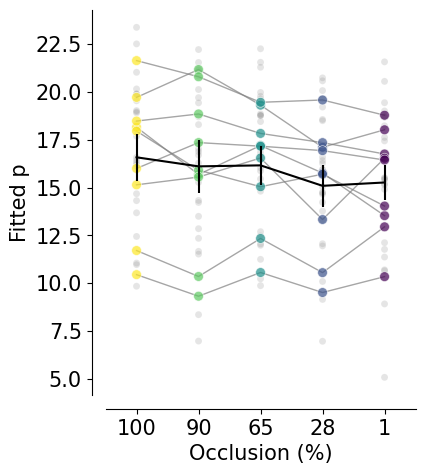

In [125]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))

#optimal_df["mouse_name"] = optimal_df.dataset.str.split("_").str [0]
counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_multi_aperture,
)
ax.invert_xaxis()

ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Fitted p")
ax.set_xlim(-0.5, 4.5)

ax.set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(save_fig_path + "figure4_fitted_p.svg", transparent=True)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

2025-06-30 15:46:35,194::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:46:35,194::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:46:35,200::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:46:35,200::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:46:35,241::INFO::category.py::Using categorical un

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  3.1376 4.0000 96.0000 0.0180



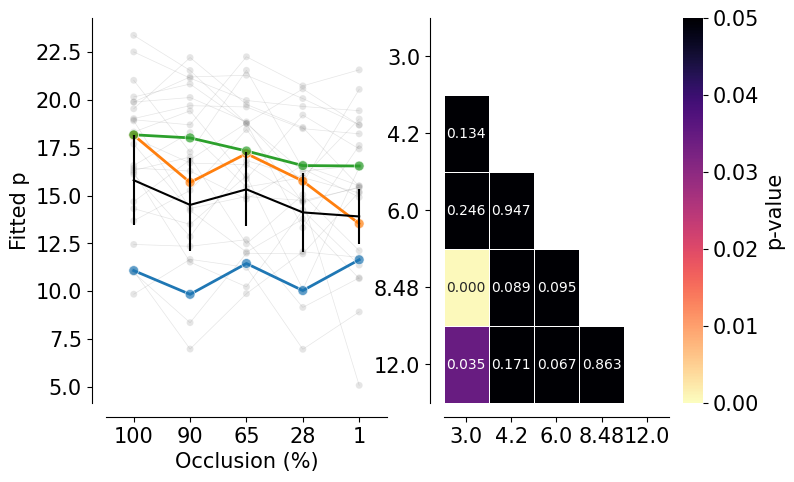

In [124]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

counts = (
    optimal_df
    .groupby(["lab_id", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_lab=True,
    cmap=plotting.colors_multi_aperture,
)
ax[0].invert_xaxis()

ax[0].set_xlabel("Occlusion (%)")
ax[0].set_ylabel("Fitted p")
ax[0].set_xlim(-0.5, 4.5)

ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

p_values = get_multi_performance_p_val(optimal_df,  y_var="optimal_p")
plot_aperture_heatmap(p_values, ax= ax[1])

sns.despine(offset=10, ax=ax[1])

print(AnovaRM(counts, depvar="count", subject="dataset", within=["aperture"]).fit())
plt.savefig(
    save_fig_path + "figure4_multi_occluder_fitted_p_per_lab.svg",
    transparent=True,
)

In [103]:
inter_df["aperture"] = inter_df["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=inter_df, label=regression.model_labels, per_mouse=True
)

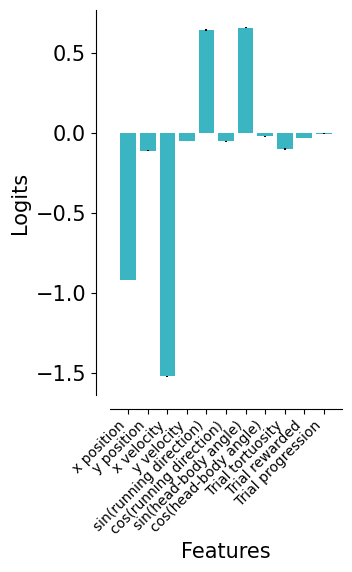

In [104]:
# Logits of the regression
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
ax.bar(
    regression.model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#3AB5C1",
)
sns.despine(offset=10, ax=ax)

ax.set_xticks(np.arange(len(regression.model_labels)))
ax.set_xticklabels(regression.clean_model_labels, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Logits")
ax.set_xlabel("Features")

plt.savefig(
    save_fig_path + "figure4_multi_occluder_model_logits.svg", transparent=False
)

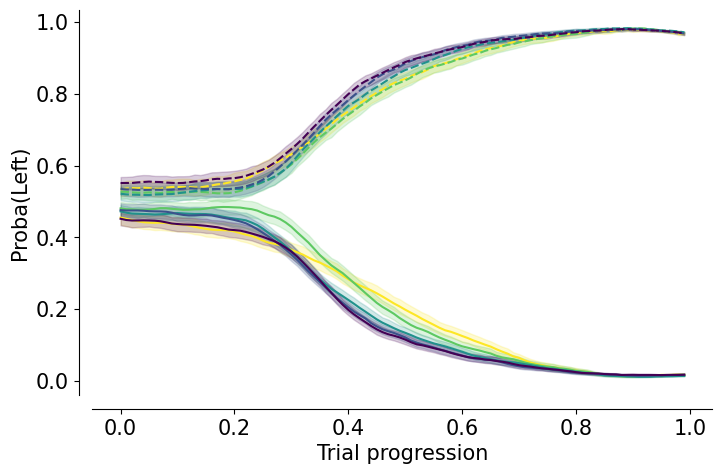

In [105]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.lineplot(
    data=df_model,
    x="trial_length",
    y="proba_left",
    hue="aperture",
    style="trial_left_choice",
    palette=plotting.colors_multi_aperture,
    sort=False,
    alpha=1,
    ax=ax,
)
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(
    save_fig_path + "figure4_multi_dynamic_decision_variable_mean.svg", transparent=True
)

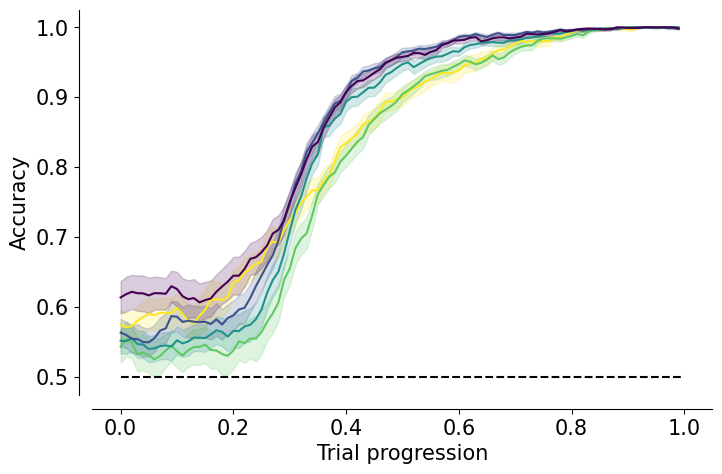

In [106]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

mean_mouse = df_model.groupby(["dataset", "aperture", "trial_length"]).mean(
    numeric_only=True
)

mean_mouse_per_choice = df_model.groupby(
    ["dataset", "trial_left_choice", "aperture", "trial_length"]
).mean(numeric_only=True)

# Accuracy
sns.lineplot(
    ax=ax,
    data=mean_mouse,
    y="accuracy",
    x="trial_length",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    errorbar="se",
)
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Accuracy")
ax.hlines(0.5, 0, 1, color="black", linestyle="--")
plt.legend([], [], frameon=False)
plt.savefig(
    save_fig_path + "figure4_multi_occluder_model_accuracy.svg", transparent=False
)

In [107]:
df_model["trial_length_bin"] = pd.cut(
    df_model["trial_length"], bins=50
)  # Adjust bins as needed
df_anova = df_model.groupby(
    ["dataset", "aperture", "trial_length_bin"], as_index=False
)["accuracy"].mean()

print(
    AnovaRM(
        data=df_anova,
        depvar="accuracy",
        subject="dataset",
        within=["aperture", "trial_length_bin"],
    ).fit()
)

                           Anova
                          F Value   Num DF    Den DF  Pr > F
------------------------------------------------------------
aperture                   11.0980   4.0000   96.0000 0.0000
trial_length_bin          439.6023  49.0000 1176.0000 0.0000
aperture:trial_length_bin   4.5326 196.0000 4704.0000 0.0000



In [108]:
df_model["session"] = df_model["dataset"]
df_model["trial_L_choice"] = df_model["trial_left_choice"]
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)

2025-06-30 15:16:49,687::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:16:49,687::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:16:49,693::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:16:49,693::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:16:49,801::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=2.0346043215583185, pvalue=0.0530823177141026, df=24)
3.0-6.0: TtestResult(statistic=4.6344257241860705, pvalue=0.00010520738946731549, df=24)
3.0-8.48: TtestResult(statistic=6.909747438365419, pvalue=3.8085109996891383e-07, df=24)
4.2-6.0: TtestResult(statistic=3.0409910657995955, pvalue=0.005628691676426512, df=24)
4.2-8.48: TtestResult(statistic=5.121720981757489, pvalue=3.054550722305851e-05, df=24)
6.0-8.48: TtestResult(statistic=4.992659115167972, pvalue=4.234916305737267e-05, df=24)
12.0-3.0: TtestResult(statistic=-9.1623900597833, pvalue=2.6372125124063355e-09, df=24)
12.0-4.2: TtestResult(statistic=-7.004954973370708, pvalue=3.045365382218108e-07, df=24)
12.0-6.0: TtestResult(statistic=-6.449772479020231, pvalue=1.1396006207463743e-06, df=24)
12.0-8.48: TtestResult(statistic=-1.9268923669989877, pvalue=0.06591300316377614, df=24)


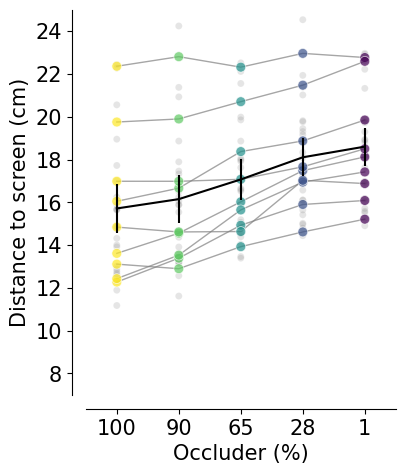

In [109]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
_ = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.set_ylim(7, 25)
ax.set_xlim(-0.5, 4.5)
ax.set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure4_multi_occluder_decision_points_distance.svg",
    transparent=True,
)

In [120]:
decision_points["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    decision_points.loc[decision_points.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2025-06-30 15:34:27,751::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:34:27,751::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:34:27,762::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:34:27,762::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-06-30 15:34:27,811::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=2.0346043215583185, pvalue=0.0530823177141026, df=24)
3.0-6.0: TtestResult(statistic=4.6344257241860705, pvalue=0.00010520738946731549, df=24)
3.0-8.48: TtestResult(statistic=6.909747438365422, pvalue=3.808510999689104e-07, df=24)
4.2-6.0: TtestResult(statistic=3.0409910657995955, pvalue=0.005628691676426512, df=24)
4.2-8.48: TtestResult(statistic=5.1217209817574885, pvalue=3.054550722305862e-05, df=24)
6.0-8.48: TtestResult(statistic=4.992659115167972, pvalue=4.234916305737267e-05, df=24)
12.0-3.0: TtestResult(statistic=-9.162390059783299, pvalue=2.6372125124063446e-09, df=24)
12.0-4.2: TtestResult(statistic=-7.00495497337071, pvalue=3.045365382218097e-07, df=24)
12.0-6.0: TtestResult(statistic=-6.449772479020229, pvalue=1.1396006207463785e-06, df=24)
12.0-8.48: TtestResult(statistic=-1.9268923669989877, pvalue=0.06591300316377614, df=24)
                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture 34.3426 

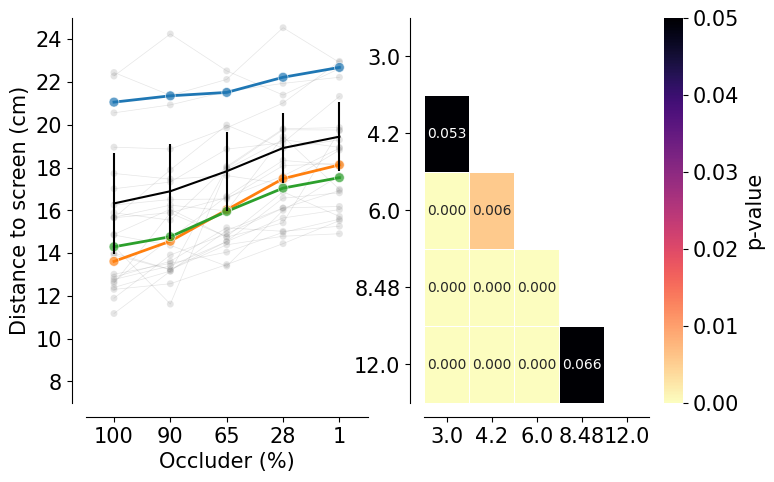

In [123]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

_ = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[0].set_ylim(7, 25)
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

p_values = get_multi_performance_p_val(decision_points,  y_var="y")
plot_aperture_heatmap(p_values, ax= ax[1])

sns.despine(offset=10, ax=ax[1])

decision_points_anova = decision_points.groupby(["dataset", "aperture"], as_index=False)[
    "y"
].mean()
print(AnovaRM(decision_points_anova, depvar="y", subject="dataset", within=["aperture"]).fit())


plt.savefig(
    save_fig_path + "figure4_multi_occluder_decision_points_distance_per_lab.svg",
    transparent=True,
)